In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from simlm.analysis import (
    load_and_process_results,
    plot_metric_distribution,
    plot_success_rate,
    plot_metric_by_difficulty,
    plot_iterations_histogram,
    print_summary_stats,
    plot_simlm_cot_error_ratio,
    plot_error_ratio_by_ground,
    summarize_average_error_by_ground,
    summarize_improvement_by_ground,
    summarize_relative_improvement,
    plot_error_vs_ground_difficulty,
    summarize_failure_rate,
    plot_iterations_vs_error,
    plot_histogram_error_distribution,
    perform_statistical_tests
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Configurations
RESULTS_DIR = Path("results") 
RESULT_FILE = RESULTS_DIR / "experiment_results-1260.jsonl" 
sns.set_theme(style="whitegrid")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 100 # Adjust plot resolution if needed

In [2]:
results_df = load_and_process_results(RESULT_FILE)

Loading results from: results/experiment_results-1260.jsonl
Processed 1259 valid results.


In [3]:
# Summary stats
print("\nOverview")
results_df.info()

print("\nCounts")
print("Strategies:\n", results_df['Strategy'].value_counts())
print("\nExperiment Conditions:\n", results_df['Experiment Condition'].value_counts())
print("\nLLM Models:\n", results_df['LLM Model Name'].value_counts())

print_summary_stats(results_df)


Overview
<class 'pandas.core.frame.DataFrame'>
Index: 1259 entries, 0 to 1259
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Timestamp                     1259 non-null   datetime64[ns]
 1   Success                       1259 non-null   bool          
 2   Error                         1259 non-null   object        
 3   Time Taken (s)                833 non-null    float64       
 4   Iterations Run                1259 non-null   int64         
 5   Final Height (m)              833 non-null    float64       
 6   Final Velocity (m/s)          833 non-null    float64       
 7   Actual Distance Bounce 3 (m)  833 non-null    float64       
 8   Bounce Locations (m)          833 non-null    object        
 9   Strategy                      1259 non-null   object        
 10  Target Distance (m)           1259 non-null   float64       
 11  Max Iterations Allowed   

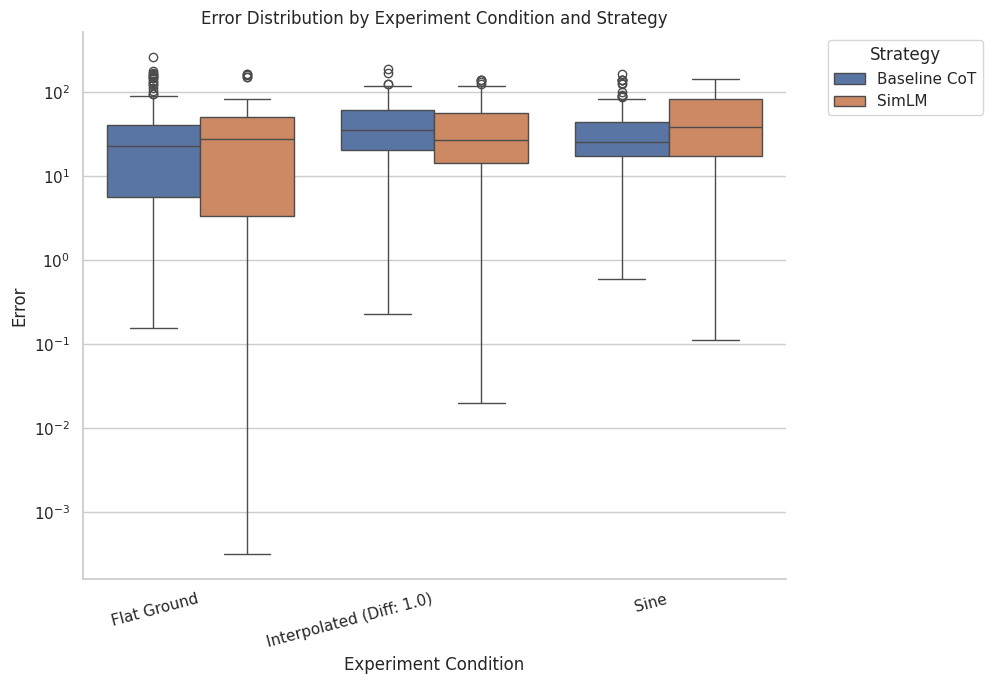

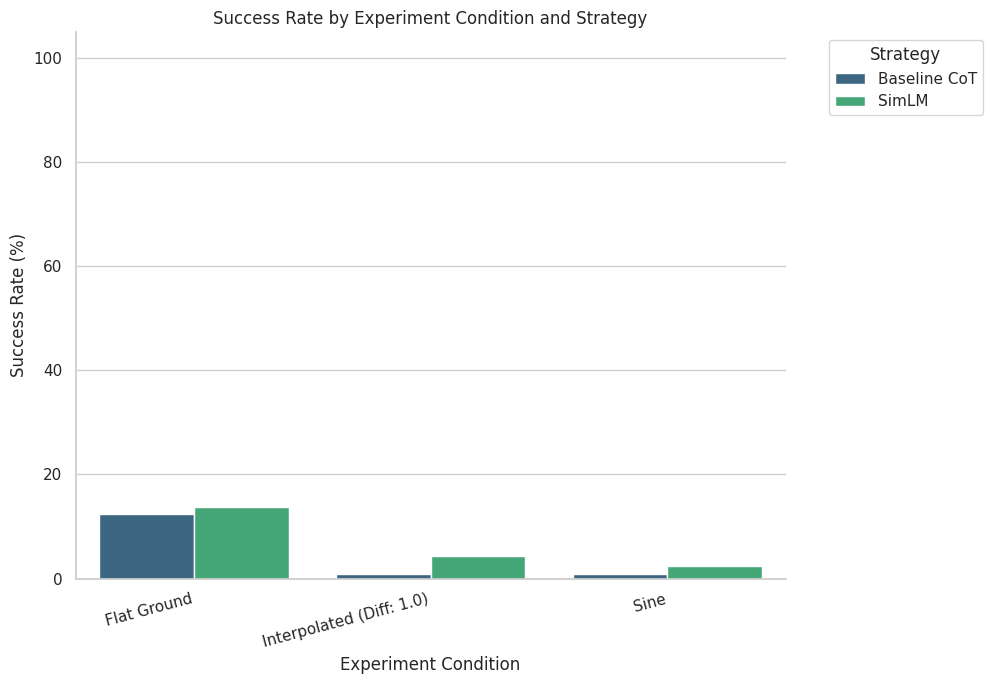

In [4]:
##### Strategy Comparison #####

# Error Distribution
plot_metric_distribution(
    results_df,
    metric_col='Error',
    group_col='Experiment Condition', 
    hue_col='Strategy',
    title='Error Distribution by Experiment Condition and Strategy',
    yscale='log' 
)

# Success Rate
plot_success_rate(
    results_df,
    group_col='Experiment Condition',
    hue_col='Strategy',
    title='Success Rate by Experiment Condition and Strategy'
)

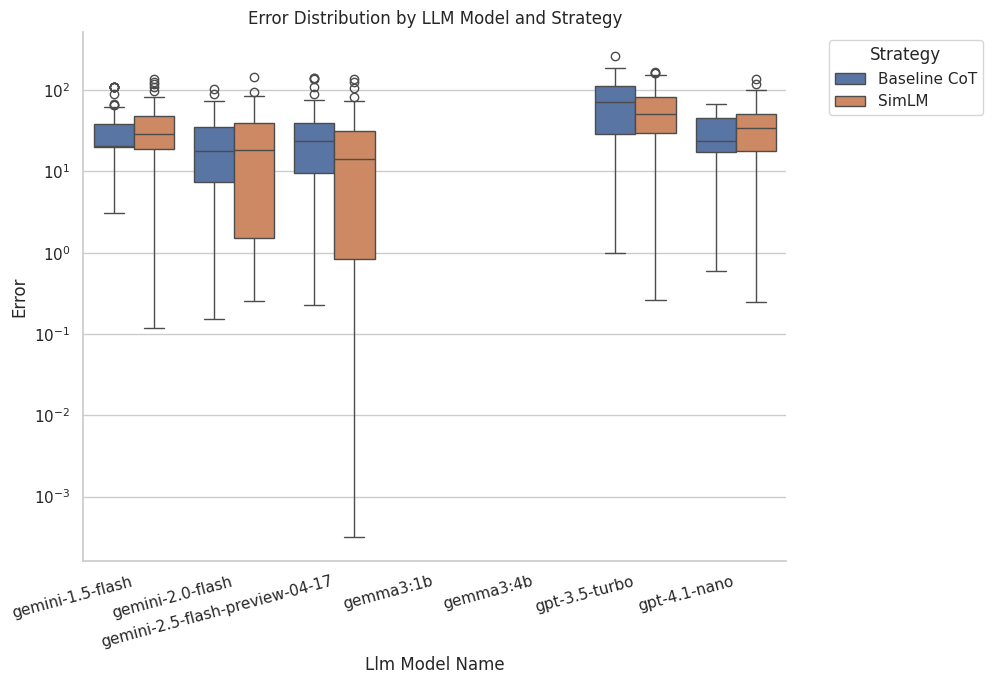

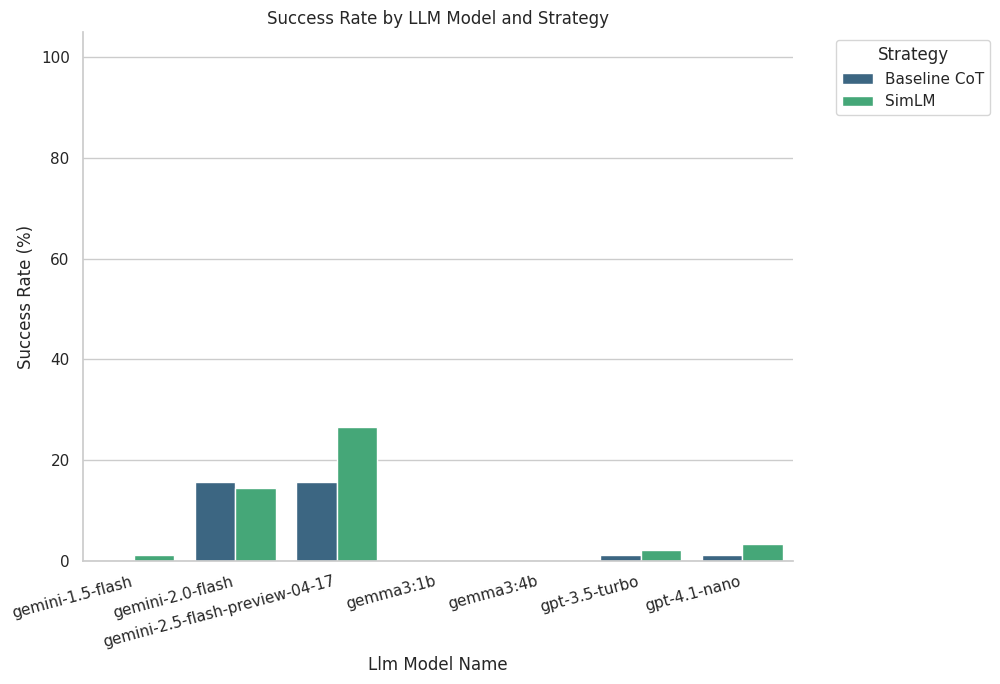

In [5]:
##### LLM Comparison #####

# Error Distribution
plot_metric_distribution(
    results_df,
    metric_col='Error',
    group_col='LLM Model Name',
    hue_col='Strategy',
    title='Error Distribution by LLM Model and Strategy',
    yscale='log'
)

# Success Rate
plot_success_rate(
    results_df,
    group_col='LLM Model Name',
    hue_col='Strategy',
    title='Success Rate by LLM Model and Strategy'
)

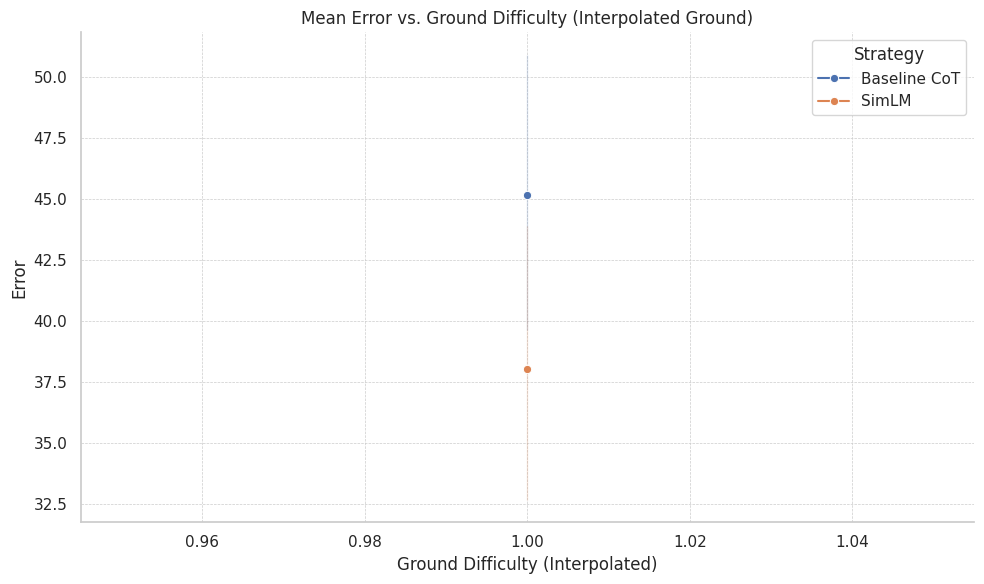

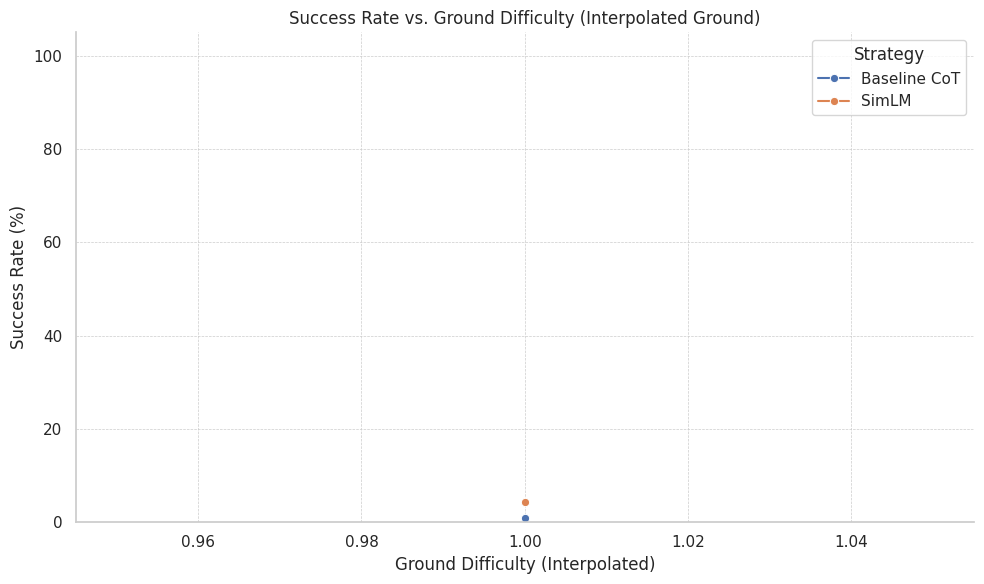

In [6]:
##### Experiment C #####

# Error vs. Difficulty
plot_metric_by_difficulty(
        results_df,
        metric_col='Error',
        title='Mean Error vs. Ground Difficulty (Interpolated Ground)'
)

# Success Rate vs. Difficulty

exp_c_df_succ = results_df[results_df['Ground Type'] == 'Interpolated'].copy()
success_by_diff = exp_c_df_succ.groupby(['Ground Difficulty', 'Strategy'], observed=False)['Success'].mean().reset_index()
success_by_diff['Success Rate (%)'] = success_by_diff['Success'] * 100

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=success_by_diff,
    x='Ground Difficulty',
    y='Success Rate (%)',
    hue='Strategy',
    marker='o'
)
plt.title('Success Rate vs. Ground Difficulty (Interpolated Ground)')
plt.xlabel("Ground Difficulty (Interpolated)")
plt.ylabel('Success Rate (%)')
plt.ylim(0, 105)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Strategy')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


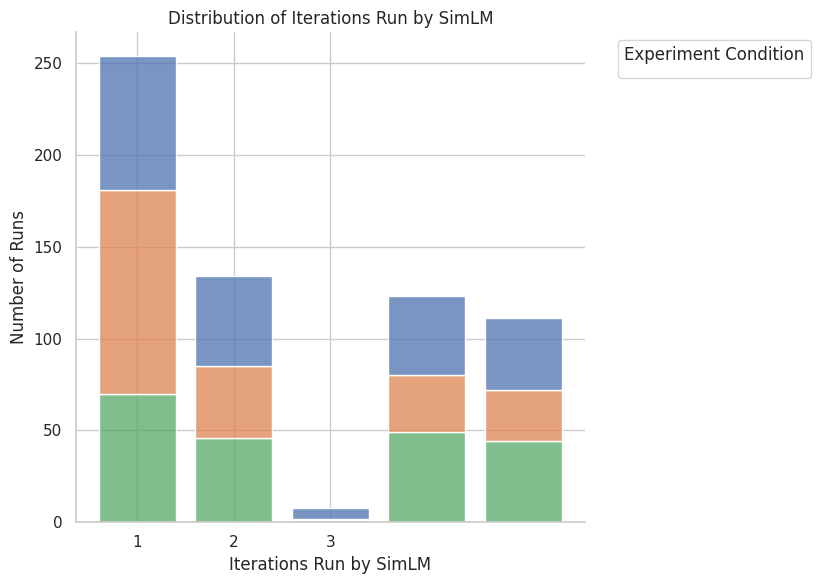

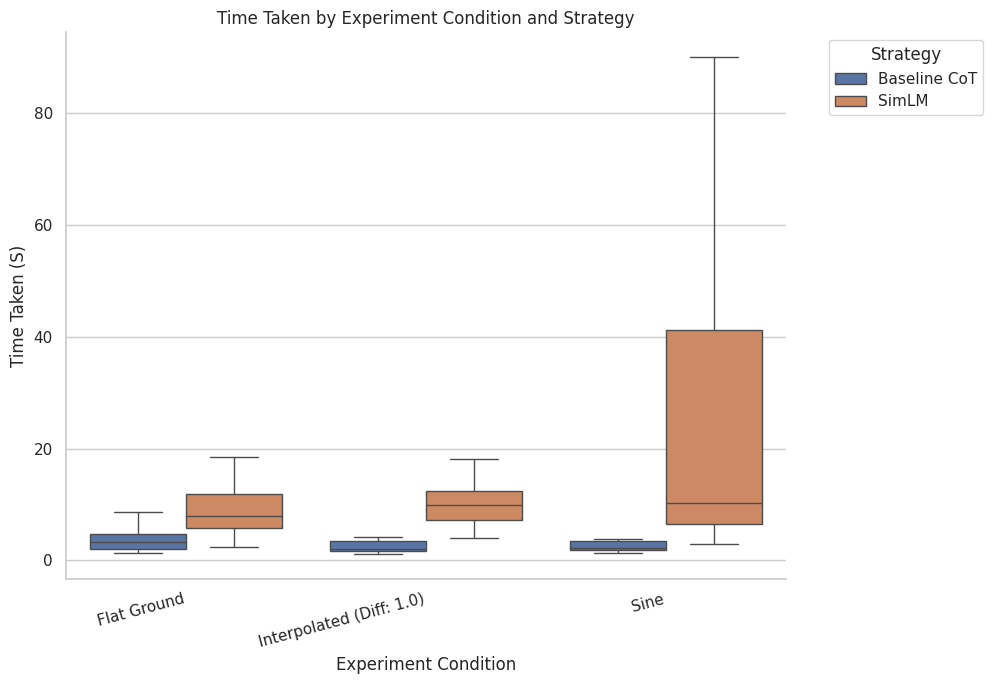

In [7]:
##### General analysis #####

# Iterations 
plot_iterations_histogram(
    results_df,
    title='Distribution of Iterations Run by SimLM'
)

# Time Taken Comparison
plot_metric_distribution(
    results_df,
    metric_col='Time Taken (s)',
    group_col='Experiment Condition',
    hue_col='Strategy',
    title='Time Taken by Experiment Condition and Strategy',
    showfliers=False 
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Strategy                        Baseline CoT      SimLM
LLM Model Name                                         
gemini-1.5-flash                   34.711372  38.536636
gemini-2.0-flash                   23.088681  27.206111
gemini-2.5-flash-preview-04-17     30.268674  21.043837
gpt-3.5-turbo                      76.223161  56.905399
gpt-4.1-nano                       29.524637  37.923929


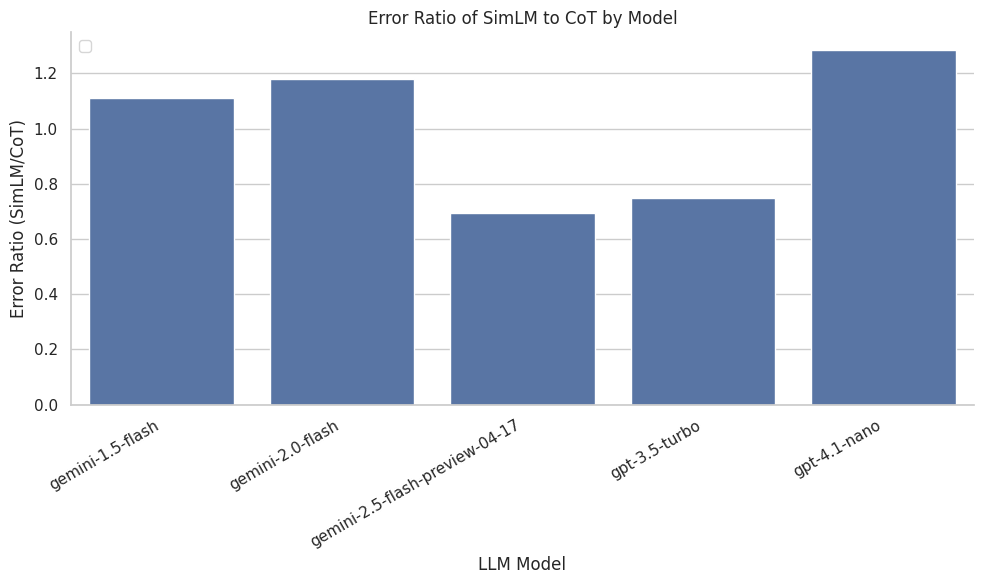

In [8]:
plot_simlm_cot_error_ratio(results_df)

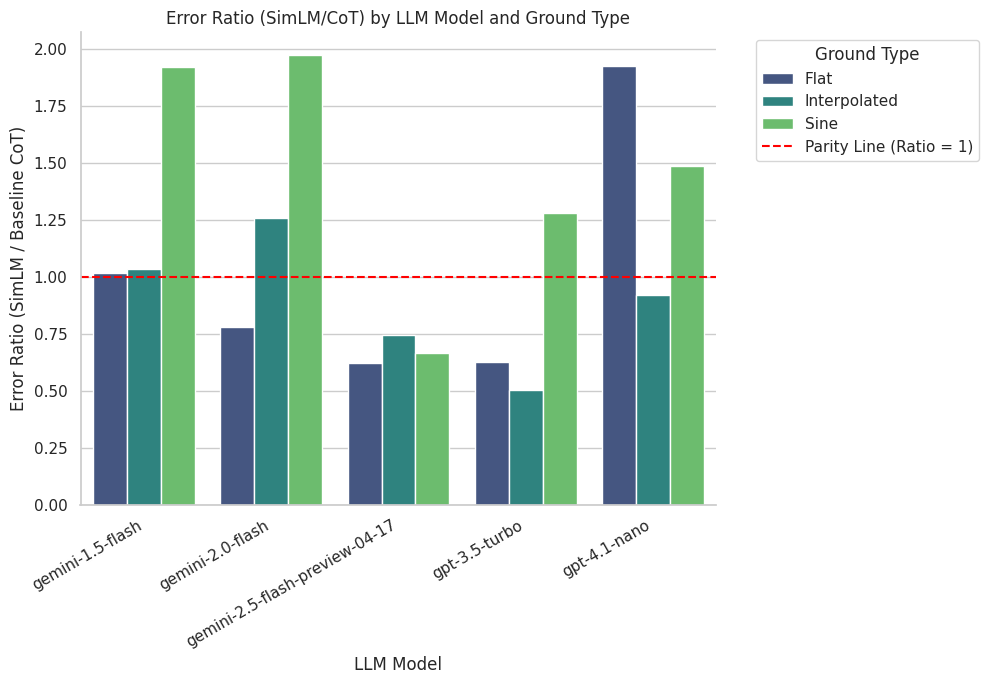

In [9]:
plot_error_ratio_by_ground(results_df)

In [10]:
summarize_average_error_by_ground(results_df)


--- Average Error by LLM Model and Ground Type ---


Ground Type,Flat,Interpolated,Sine
LLM Model Name,,,
gemini-1.5-flash,25.82,49.95,30.80
gemini-2.0-flash,12.28,35.87,27.98
gemini-2.5-flash-preview-04-17,9.18,29.70,37.87
gpt-3.5-turbo,90.23,47.40,62.05
gpt-4.1-nano,27.71,44.48,28.98


In [11]:
summarize_improvement_by_ground(results_df)


--- Improvement (Baseline CoT - SimLM) by LLM Model and Ground Type ---


Ground Type,Flat,Interpolated,Sine
LLM Model Name,,,
gemini-1.5-flash,-0.37,-1.78,-27.53
gemini-2.0-flash,3.01,-8.35,-22.63
gemini-2.5-flash-preview-04-17,4.30,8.81,15.30
gpt-3.5-turbo,41.68,31.45,-15.18
gpt-4.1-nano,-17.53,3.68,-11.35


In [12]:
summarize_relative_improvement(results_df)


--- Relative Improvement (%) by LLM Model and Ground Type ---


Ground Type,Flat,Interpolated,Sine
LLM Model Name,,,
gemini-1.5-flash,-1.5,-3.6,-92.0
gemini-2.0-flash,22.0,-25.8,-97.5
gemini-2.5-flash-preview-04-17,38.1,25.7,33.6
gpt-3.5-turbo,37.5,49.8,-27.9
gpt-4.1-nano,-92.5,7.9,-48.7


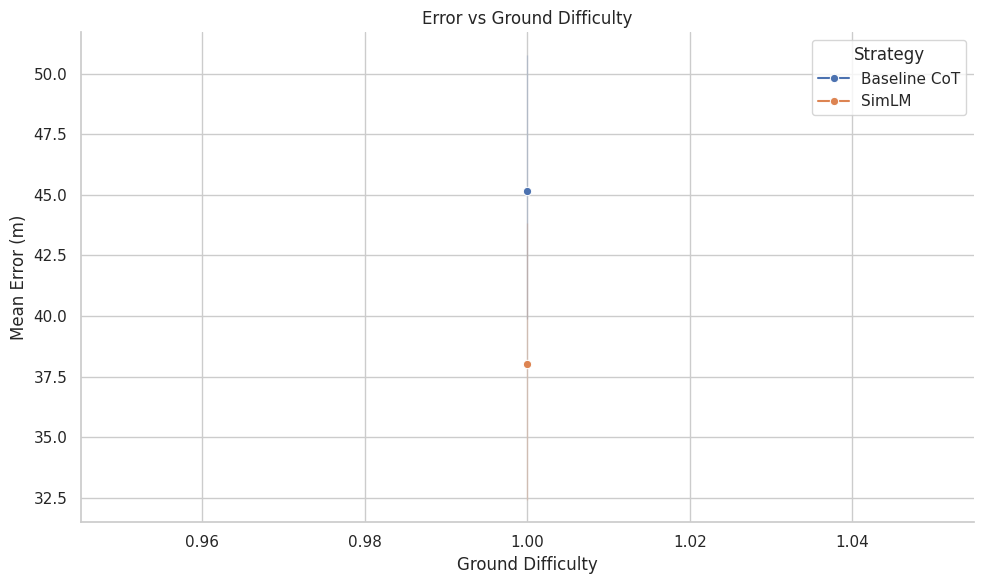

In [13]:
plot_error_vs_ground_difficulty(results_df)

In [14]:
summarize_failure_rate(results_df)


--- Failure Rate (%) by LLM Model and Strategy ---


LLM Model Name                  Strategy    
gemini-1.5-flash                Baseline CoT    68.9
                                SimLM           47.8
gemini-2.0-flash                Baseline CoT    46.7
                                SimLM           30.0
gemini-2.5-flash-preview-04-17  Baseline CoT    55.1
                                SimLM           35.6
gemma3:1b                       Baseline CoT     0.0
                                SimLM            0.0
gemma3:4b                       Baseline CoT     0.0
                                SimLM            0.0
gpt-3.5-turbo                   Baseline CoT    84.4
                                SimLM           78.9
gpt-4.1-nano                    Baseline CoT    58.9
                                SimLM           68.9
Name: Failure, dtype: float64

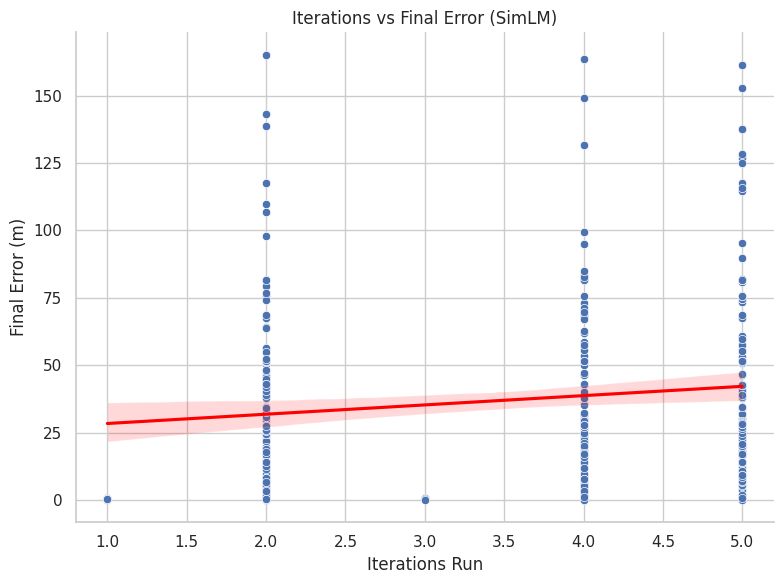

In [15]:
plot_iterations_vs_error(results_df)

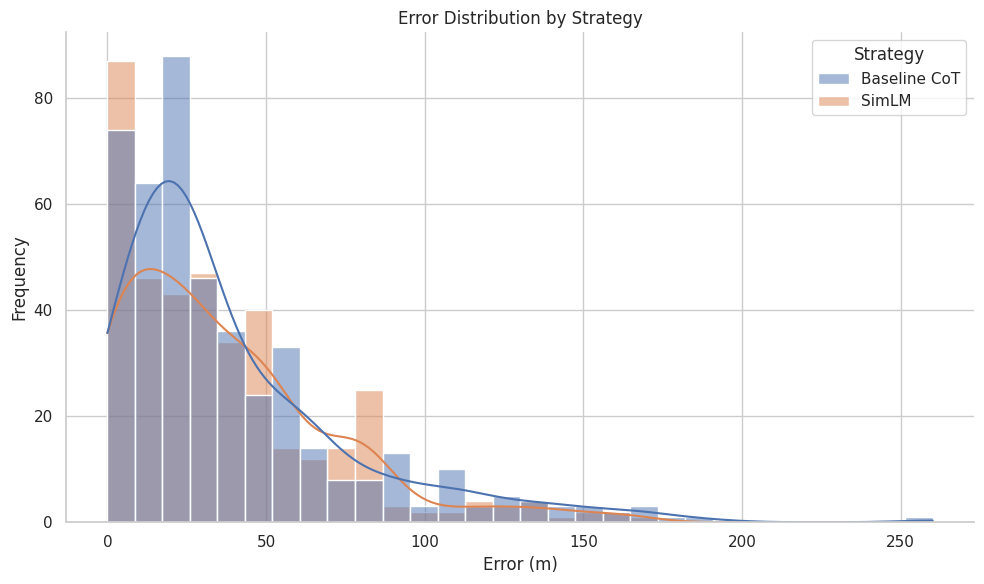

In [16]:
plot_histogram_error_distribution(results_df)

In [17]:
perform_statistical_tests(results_df)


--- Statistical Significance Tests (Baseline CoT vs SimLM for Error) ---

Testing for Group: Flat Ground
  Baseline CoT Mean Error: 36.132 (N=150)
  SimLM Mean Error: 30.468 (N=146)
  T-statistic: 1.232, P-value: 0.219
  Difference significant at alpha=0.05? No (p=0.219)

Testing for Group: Sine
  Baseline CoT Mean Error: 35.283 (N=150)
  SimLM Mean Error: 45.045 (N=99)
  T-statistic: -2.320, P-value: 0.0213
  Difference significant at alpha=0.05? Yes (p=0.0213)

Testing for Group: Interpolated (Diff: 1.0)
  Baseline CoT Mean Error: 45.143 (N=147)
  SimLM Mean Error: 38.033 (N=141)
  T-statistic: 1.754, P-value: 0.0806
  Difference significant at alpha=0.05? No (p=0.0806)
--------------------------------------------------


,Group,Stat,P-Value,Significant,N1,N2
0,Flat Ground,1.231959,0.219050,No (p=0.219),150,146
1,Sine,-2.320364,0.021333,Yes (p=0.0213),150,99
2,Interpolated (Diff: 1.0),1.753624,0.080567,No (p=0.0806),147,141
